In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip -q install GEOparse scikit-survival lifelines
import GEOparse, pandas as pd, numpy as np

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 36.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [3]:
gse = GEOparse.get_GEO(geo="GSE10846", destdir="/kaggle/working")

# Expression matrix: probes x samples
expr = gse.pivot_samples("VALUE")
print(expr.shape)  # ~54k probes x 414 samples

# Clinical metadata from sample characteristics
meta = pd.DataFrame({gsm_name: gsm.metadata.get("characteristics_ch1", [])
                     for gsm_name, gsm in gse.gsms.items()}).T
meta.head(10)

30-Aug-2026 19:20:38 DEBUG utils - Directory /kaggle/working already exists. Skipping.
30-Aug-2026 19:20:38 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10846/soft/GSE10846_family.soft.gz to /kaggle/working/GSE10846_family.soft.gz
100%|██████████| 124M/124M [00:01<00:00, 127MB/s]  
30-Aug-2026 19:20:39 DEBUG downloader - Size validation passed
30-Aug-2026 19:20:39 DEBUG downloader - Moving /tmp/tmp3_fh0gn1 to /kaggle/working/GSE10846_family.soft.gz
30-Aug-2026 19:20:39 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE10nnn/GSE10846/soft/GSE10846_family.soft.gz
30-Aug-2026 19:20:39 INFO GEOparse - Parsing /kaggle/working/GSE10846_family.soft.gz: 
30-Aug-2026 19:20:39 DEBUG GEOparse - DATABASE: GeoMiame
30-Aug-2026 19:20:39 DEBUG GEOparse - SERIES: GSE10846
30-Aug-2026 19:20:39 DEBUG GEOparse - PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. S

(54675, 420)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
GSM274895,Gender: male,Age: 52,Tissue: lymph node,Disease state: Lymphoma,Individual: 549,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: GCB...,Clinical info: Follow up status: DEAD,Clinical info: Follow up years: 2.68,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 3,Clinical info: LDH ratio: NA,Clinical info: Number of extranodal sites: 0
GSM274896,Gender: male,Age: 75,Tissue: lymph node,Disease state: Lymphoma,Individual: 553,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: GCB...,Clinical info: Follow up status: DEAD,Clinical info: Follow up years: 0.82,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 0,Clinical info: Stage: 3,Clinical info: LDH ratio: 1.12,Clinical info: Number of extranodal sites: 0
GSM274897,Gender: female,Age: 76,Tissue: lymph node,Disease state: Lymphoma,Individual: 689,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: DEAD,Clinical info: Follow up years: 2.54,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 3,Clinical info: Stage: 1,Clinical info: LDH ratio: 1.01,Clinical info: Number of extranodal sites: 0
GSM274898,Gender: female,Age: 56,Tissue: lymph node,Disease state: Lymphoma,Individual: 704,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: ALIVE,Clinical info: Follow up years: 9.67,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 3,Clinical info: LDH ratio: 1.380952381,Clinical info: Number of extranodal sites: 0
GSM274899,Gender: male,Age: 46,Tissue: lymph node,Disease state: Lymphoma,Individual: 694,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: ALIVE,Clinical info: Follow up years: 4.83,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 2,Clinical info: LDH ratio: 0.68,Clinical info: Number of extranodal sites: 0
GSM274900,Gender: male,Age: 36,Tissue: lymph node,Disease state: Lymphoma,Individual: 756,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: ALIVE,Clinical info: Follow up years: 7.21,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 0,Clinical info: Stage: 1,Clinical info: LDH ratio: 0.69047619,Clinical info: Number of extranodal sites: 0
GSM274901,Gender: female,Age: 18,Tissue: lymph node,Disease state: Lymphoma,Individual: 547,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: DEAD,Clinical info: Follow up years: 0.05,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 4,Clinical info: LDH ratio: NA,Clinical info: Number of extranodal sites: 1
GSM274902,Gender: male,Age: 62,Tissue: lymph node,Disease state: Lymphoma,Individual: 841,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: ABC...,Clinical info: Follow up status: ALIVE,Clinical info: Follow up years: 10.14,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 2,Clinical info: LDH ratio: 2.56,Clinical info: Number of extranodal sites: 0
GSM274903,Gender: NA,Age: 70,Tissue: lymph node,Disease state: Lymphoma,Individual: 745,Clinical info: Submitting diagnosis: DLBCL,Clinical info: Final microarray diagnosis: GCB...,Clinical info: Follow up status: DEAD,Clinical info: Follow up years: 1.33,Clinical info: Chemotherapy: CHOP-Like Regimen,Clinical info: ECOG performance status: 1,Clinical info: Stage: 2,Cl

In [8]:
def parse_chars(gsm):
    d = {}
    for c in gsm.metadata.get("characteristics_ch1", []):
        c = c.strip()
        # strip the "Clinical info:" wrapper if present
        low = c.lower()
        if low.startswith("clinical info:"):
            c = c.split(":", 1)[1].strip()
        if ":" in c:
            k, v = c.split(":", 1)
            k, v = k.strip().lower(), v.strip()
            # don't overwrite: some GSMs have dup keys
            if k in d:
                k = k + "_2"
            d[k] = v
    return d

clin = pd.DataFrame({name: parse_chars(g) for name, g in gse.gsms.items()}).T
print(clin.columns.tolist())
clin.head()

['gender', 'age', 'tissue', 'disease state', 'individual', 'submitting diagnosis', 'final microarray diagnosis', 'follow up status', 'follow up years', 'chemotherapy', 'ecog performance status', 'stage', 'ldh ratio', 'number of extranodal sites']


,gender,age,tissue,disease state,individual,submitting diagnosis,final microarray diagnosis,follow up status,follow up years,chemotherapy,ecog performance status,stage,ldh ratio,number of extranodal sites
GSM274895,male,52,lymph node,Lymphoma,549,DLBCL,GCB DLBCL,DEAD,2.68,CHOP-Like Regimen,1,3,NA,0
GSM274896,male,75,lymph node,Lymphoma,553,DLBCL,GCB DLBCL,DEAD,0.82,CHOP-Like Regimen,0,3,1.12,0
GSM274897,female,76,lymph node,Lymphoma,689,DLBCL,ABC DLBCL,DEAD,2.54,CHOP-Like Regimen,3,1,1.01,0
GSM274898,female,56,lymph node,Lymphoma,704,DLBCL,ABC DLBCL,ALIVE,9.67,CHOP-Like Regimen,1,3,1.380952381,0
GSM274899,male,46,lymph node,Lymphoma,694,DLBCL,ABC DLBCL,ALIVE,4.83,CHOP-Like Regimen,1,2,0.68,0


In [6]:
clin = pd.DataFrame({name: parse_chars(g) for name, g in gse.gsms.items()}).T
print(clin.columns.tolist())
clin.head()

['gender', 'age', 'tissue', 'disease state', 'individual', 'clinical info']


,gender,age,tissue,disease state,individual,clinical info
GSM274895,male,52,lymph node,Lymphoma,549,Number of extranodal sites: 0
GSM274896,male,75,lymph node,Lymphoma,553,Number of extranodal sites: 0
GSM274897,female,76,lymph node,Lymphoma,689,Number of extranodal sites: 0
GSM274898,female,56,lymph node,Lymphoma,704,Number of extranodal sites: 0
GSM274899,male,46,lymph node,Lymphoma,694,Number of extranodal sites: 0


In [7]:
gpl = gse.gpls[list(gse.gpls.keys())[0]].table  # GPL570 annotation
probe2gene = gpl.set_index("ID")["Gene Symbol"].str.split(" /// ").str[0]

expr_g = expr.copy()
expr_g["gene"] = expr_g.index.map(probe2gene)
expr_g = expr_g.dropna(subset=["gene"])
# keep highest-variance probe per gene
variances = expr_g.drop(columns="gene").var(axis=1)
expr_g = expr_g.loc[variances.groupby(expr_g["gene"]).idxmax().values]
expr_g = expr_g.set_index("gene").drop(columns=[], errors="ignore")
print(expr_g.shape)  # ~20k genes x 414

(22880, 420)


In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.DataFrame(index=clin.index)
df["time_yrs"] = pd.to_numeric(clin.filter(like="follow up").iloc[:,0], errors="coerce")
df["event"] = clin.filter(like="status").iloc[:,0].str.contains("DEAD", case=False, na=False).astype(int)
df["age"] = pd.to_numeric(clin.get("age", clin.filter(like="age").iloc[:,0]), errors="coerce")
df["rchop"] = clin.filter(like="chemo").iloc[:,0].str.contains("Rituximab|R-CHOP", case=False, na=False).astype(int)
print(df["event"].value_counts(), df["rchop"].value_counts())
df.describe()

event
0    255
1    165
Name: count, dtype: int64 rchop
1    233
0    187
Name: count, dtype: int64


,time_yrs,event,age,rchop
count,0.0,420.000000,414.000000,420.000000
mean,NaN,0.392857,61.140097,0.554762
std,NaN,0.488968,15.445591,0.497585
min,NaN,0.000000,14.000000,0.000000
25%,NaN,0.000000,52.000000,0.000000
50%,NaN,0.000000,62.500000,1.000000
75%,NaN,1.000000,73.750000,1.000000
max,NaN,1.000000,92.000000,1.000000


In [14]:
df = pd.DataFrame(index=clin.index)
df["time_yrs"] = pd.to_numeric(clin["follow up years"], errors="coerce")
df["event"]    = clin["follow up status"].str.upper().eq("DEAD").astype(int)
df["age"]      = pd.to_numeric(clin["age"], errors="coerce")
df["ecog"]     = pd.to_numeric(clin["ecog performance status"], errors="coerce")
df["stage"]    = pd.to_numeric(clin["stage"], errors="coerce")
df["ldh_ratio"]= pd.to_numeric(clin["ldh ratio"], errors="coerce")
df["extranodal"]= pd.to_numeric(clin["number of extranodal sites"], errors="coerce")
df["rchop"]    = clin["chemotherapy"].str.contains("Rituximab|R-CHOP", case=False, na=False).astype(int)
df["coo"]      = clin["final microarray diagnosis"]  # GCB / ABC / unclassified

# IPI (0-5): one point each
df["ipi"] = ((df["age"] > 60).astype(int)
           + (df["ldh_ratio"] > 1).astype(int)
           + (df["ecog"] >= 2).astype(int)
           + (df["stage"] >= 3).astype(int)
           + (df["extranodal"] >= 2).astype(int))
# mark IPI missing if any component missing
df.loc[df[["age","ldh_ratio","ecog","stage","extranodal"]].isna().any(axis=1), "ipi"] = np.nan

print(df["event"].value_counts())
print(df["rchop"].value_counts())
print(df["ipi"].value_counts(dropna=False).sort_index())

event
0    255
1    165
Name: count, dtype: int64
rchop
1    233
0    187
Name: count, dtype: int64
ipi
0.0    46
1.0    86
2.0    96
3.0    59
4.0    29
5.0     5
NaN    99
Name: count, dtype: int64


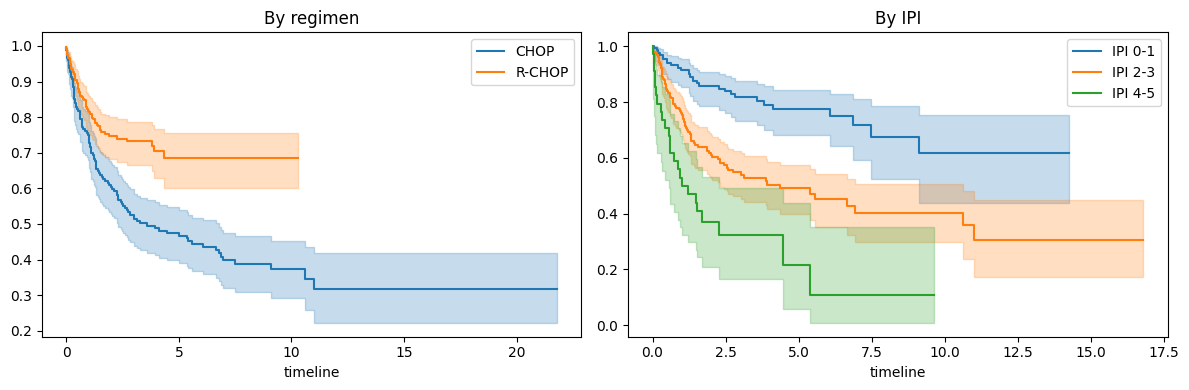

In [15]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,4))
kmf = KaplanMeierFitter()

for grp, sub in df.dropna(subset=["time_yrs"]).groupby("rchop"):
    kmf.fit(sub["time_yrs"], sub["event"], label="R-CHOP" if grp else "CHOP")
    kmf.plot_survival_function(ax=axes[0])
axes[0].set_title("By regimen")

for grp, sub in df.dropna(subset=["time_yrs"]).groupby(df["ipi"].map(
        lambda x: "0-1" if x<=1 else ("2-3" if x<=3 else "4-5") if pd.notna(x) else np.nan)):
    kmf.fit(sub["time_yrs"], sub["event"], label=f"IPI {grp}")
    kmf.plot_survival_function(ax=axes[1])
axes[1].set_title("By IPI")
plt.tight_layout()

In [16]:
!pip -q install scikit-survival
import numpy as np
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# align samples
common = df.dropna(subset=["time_yrs"]).index.intersection(expr_g.columns)
X_expr = expr_g[common].T                      # samples x genes
y = Surv.from_arrays(df.loc[common,"event"].astype(bool),
                     df.loc[common,"time_yrs"])

# reduce to top 2000 most-variable genes (speed + stability)
top = X_expr.var().nlargest(2000).index
X = X_expr[top].values

# per-cohort z-scoring (this is what will transfer cross-platform later)
X = StandardScaler().fit_transform(X)

# 5-fold CV C-index
cidx = []
for tr, te in KFold(5, shuffle=True, random_state=42).split(X):
    m = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=1000)
    m.fit(X[tr], y[tr])
    pred = m.predict(X[te])
    cidx.append(concordance_index_censored(
        y[te]["event"], y[te]["time"], pred)[0])
print(f"Expression-only C-index: {np.mean(cidx):.3f} ± {np.std(cidx):.3f}")

/tmp/ipykernel_58/51597592.py:26: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=1000).
  m.fit(X[tr], y[tr])
/tmp/ipykernel_58/51597592.py:26: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=1000).
  m.fit(X[tr], y[tr])
/tmp/ipykernel_58/51597592.py:26: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=1000).
  m.fit(X[tr], y[tr])
/tmp/ipykernel_58/51597592.py:26: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=1000).
  m.fit(X[tr], y[tr])


Expression-only C-index: 0.621 ± 0.042


/tmp/ipykernel_58/51597592.py:26: ConvergenceWarning: Optimization terminated early, you might want to increase the number of iterations (max_iter=1000).
  m.fit(X[tr], y[tr])


In [17]:
ipi_mask = df.loc[common, "ipi"].notna()
c_ipi = concordance_index_censored(
    df.loc[common,"event"][ipi_mask].astype(bool),
    df.loc[common,"time_yrs"][ipi_mask],
    df.loc[common,"ipi"][ipi_mask])[0]
print(f"IPI C-index: {c_ipi:.3f}")

IPI C-index: 0.687


In [18]:
# combined: IPI components + expression, complete-case on IPI
mask = df.loc[common, "ipi"].notna().values
Xc = np.hstack([X[mask],
                df.loc[common].loc[mask, ["age","ecog","stage","ldh_ratio","extranodal","rchop"]].values])
Xc = StandardScaler().fit_transform(Xc)
yc = y[mask]

cidx_comb, cidx_expr_cc, = [], []
for tr, te in KFold(5, shuffle=True, random_state=42).split(Xc):
    m = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100000)
    m.fit(Xc[tr], yc[tr])
    cidx_comb.append(concordance_index_censored(
        yc[te]["event"], yc[te]["time"], m.predict(Xc[te]))[0])
print(f"Expression+clinical C-index: {np.mean(cidx_comb):.3f} ± {np.std(cidx_comb):.3f}")

Expression+clinical C-index: 0.658 ± 0.068


In [19]:
sub = df.loc[common].loc[mask]
c_ipi_cc = concordance_index_censored(
    sub["event"].astype(bool), sub["time_yrs"], sub["ipi"])[0]
print(f"IPI C-index (same n={mask.sum()} subset): {c_ipi_cc:.3f}")

IPI C-index (same n=321 subset): 0.687


In [21]:
from sksurv.linear_model import CoxPHSurvivalAnalysis

cidx_2stage = []
for tr, te in KFold(5, shuffle=True, random_state=42).split(Xc):
    clin_cols = Xc[:, -6:]
    gene_cols = Xc[:, :-6]
    # stage 1: unpenalized clinical Cox
    m_clin = CoxPHSurvivalAnalysis().fit(clin_cols[tr], yc[tr])
    lp_clin_tr, lp_clin_te = m_clin.predict(clin_cols[tr]), m_clin.predict(clin_cols[te])
    # stage 2: elastic net on genes + clinical LP as one feature
    Z_tr = np.hstack([gene_cols[tr], lp_clin_tr[:, None]])
    Z_te = np.hstack([gene_cols[te], lp_clin_te[:, None]])
    m2 = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.05, max_iter=100000)
    m2.fit(Z_tr, yc[tr])
    cidx_2stage.append(concordance_index_censored(
        yc[te]["event"], yc[te]["time"], m2.predict(Z_te))[0])
print(f"Two-stage (clinical LP + genes): {np.mean(cidx_2stage):.3f} ± {np.std(cidx_2stage):.3f}")

Two-stage (clinical LP + genes): 0.665 ± 0.051


In [22]:
expr_g.to_parquet("/kaggle/working/gse10846_expr.parquet")
df.to_csv("/kaggle/working/gse10846_clin.csv")